# <a href="https://thetahat.ru/courses/ad">Введение в анализ данных</a>
## Домашнее задание 9. Условные распределения


**Правила, <font color="red">прочитайте внимательно</font>:**

1. Общее

     * Выполненную работу **в формате `ipynb`** нужно отправить по ссылке "Сдача ДЗ" на <a href="https://thetahat.ru/courses/ad"><b>странице курса</b></a>. **Работы, присланные иным способом, не принимаются.** Дедлайны указаны в боте и на сайте, они являются строгими.
     
     * Обязательно изучите <a href="https://thetahat.ru/courses/design-hw"><b>руководство по оформлению ДЗ</b></a>. В частности, оно содержит примеры случаев, когда могут быть снижены баллы.
     
     * Обратите внимание на <a href="https://thetahat.ru/courses/ai-rules"><b>правила использования ИИ-инструментов</b></a> при решении домашнего задания.
     
     * Выполнять задание необходимо полностью самостоятельно. **При обнаружении списывания (в т.ч. злоупотребление ИИ) всем участникам списывания дается штраф -3 скор-балла к итоговой оценке.**
     
     * Решение теоретических задач оформляйте в markdown-ячейках формате $\LaTeX$. При решении можно использовать ИИ-инструменты только для оформления написанного самостоятельно решения. Например, написать черновик формул и попросить ИИ оформить эти формулы в $\LaTeX$.
     
     * Решение проверяется системой ИИ-проверки <a href="https://thetahat.ru/"><img src="https://miptstats.github.io/theta_grader_small.png" style="display: inline; vertical-align: middle;"></a> **ThetaGrader**. Результат проверки валидируется и исправляется человеком, после чего комментарии отправляются студентам.
     </br>

2. Правила заполнения ноутбука

     * Запрещается удалять имеющиеся в ноутбуке ячейки, менять местами положения существующих ячеек.
     * Отвечайте на вопросы, а также добавляйте новые ячейки в любом количестве в предложенных местах, которые обозначены `<...>`.
     * Сохраняйте естественный линейный порядок повествования в ноутбуке сверху-вниз. Комментарии к решению пишите в markdown-ячейках.
     * Условия <font color="red"><b>запрещается модифицировать</b></font>.
     * При нарушении данных правил работа может получить 0 баллов.
</br>


**Баллы за задание**

* Задача 1 &mdash; 40 баллов
* Задача 2 &mdash; 50 баллов
* Задача 2 &mdash; 40 баллов

In [55]:
# Bot check

# HW_ID: fpmi_ad9
# Бот проверит этот ID и предупредит, если случайно сдать что-то не то.

# Status: final
# Перед отправкой в финальном решении удали "not" в строчке выше.
# Так бот проверит, что ты отправляешь финальную версию, а не промежуточную.
# Никакие значения в этой ячейке не влияют на факт сдачи работы.

In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from numpy.linalg import lstsq

import seaborn as sns

sns.set(palette="Set2")

### Ссылки на использование ИИ

Если при решении задач использовался ИИ, укажи здесь публичные ссылки на все чаты с ИИ и поясни, для каких целей он применялся. Обрати внимание на <a href="https://thetahat.ru/courses/ai-rules" target="_top">правила</a>.

**Задача 2**
1. [ссылка](https://chatgpt.com/share/69e376fe-64e0-838c-a7e3-111e45f002ba)
    - оформление формулы в LaTex
  
**Задача 3**
1. [ссылка](https://chatgpt.com/share/69e376fe-64e0-838c-a7e3-111e45f002ba)
    - оформление формул и рассуждений в латех


---
### Задача 1.


Рассмотрим датасет Breast Cancer Wisconsin Diagnostic. Это медицинский датасет про диагностику рака молочной железы. Он был собран в начале 1990-х годов в University of Wisconsin Hospitals: пациенткам с подозрительными уплотнениями в груди проводилась тонкоигольная аспирационная биопсия (FNA), полученный материал фотографировался под микроскопом, и с оцифрованных изображений автоматически выделялись границы клеточных ядер, по ним вычислялись геометрические характеристики. Итоговая версия содержит 569 образцов (212 злокачественных, 357 доброкачественных) и 30 числовых признаков.

Каждое наблюдение — это один опухолевый образец. Для каждого ядра клетки на снимке измеряются 10 базовых характеристик, а затем по всем ядрам образца считаются три агрегата: 
* среднее (`mean`), 
* «худшее»/максимальное из трёх наибольших значений (`worst`),
* стандартная ошибка (`error`). 

Так получаются 30 признаков. Рассмотрим три из них:
* `mean area` — средняя площадь ядра;
* `mean radius` — средний радиус ядра клетки, то есть среднее расстояние от центра ядра до точек на его границе (в пикселях);
* `mean concavity` — средняя выраженность вогнутых участков контура ядра (насколько глубоко граница «заходит внутрь»);

Загрузим данные

In [16]:
from sklearn.datasets import load_breast_cancer

df = load_breast_cancer(as_frame=True).frame

In [17]:
def plot_scatter(
    x_vals: np.ndarray | pd.Series,
    y_vals: np.ndarray | pd.Series,
    x_label: str,
    y_label: str,
    title: str = "",
    color: str = "#457b9d",
    ax: plt.Axes | None = None,
) -> None:
    """
    Строит скаттерплот с линией регрессии и коэффициентом корреляции в заголовке.

    Аргументы:
        x_vals: Значения переменной по оси X.
        y_vals: Значения переменной по оси Y.
        x_label: Подпись оси X.
        y_label: Подпись оси Y.
        title: Префикс заголовка графика.
        color: Цвет точек на скаттерплоте.
        ax: Оси matplotlib; если None, создаётся новая фигура.
    """

    standalone = ax is None
    if standalone:
        fig, ax = plt.subplots(figsize=(6, 4))

    r = np.corrcoef(x_vals, y_vals)[0, 1]
    ax.scatter(x_vals, y_vals, alpha=0.55, color=color)
    _add_regline(ax, x_vals, y_vals, color="gray")
    ax.set_xlabel(x_label, fontsize=11)
    ax.set_ylabel(y_label, fontsize=11)
    header = f"{title}, " if title else ""
    ax.set_title(f"{header}корреляция = {r:.3f}")
    ax.spines[["top", "right"]].set_visible(False)

    if standalone:
        plt.tight_layout()
        plt.show()

Исследуйте корреляцию между всеми парами рассматриваемых трех признаков.

In [18]:
def _add_regline(
    ax: plt.Axes,
    x_vals: np.ndarray,
    y_vals: np.ndarray,
    color: str,
    lw: float = 3,
    ci: float = 0.95,
) -> None:
    """
    Добавляет линию регрессии с доверительной полосой на переданные оси.

    Аргументы:
        ax: Оси matplotlib, на которые добавляется линия.
        x_vals: Массив значений предиктора.
        y_vals: Массив значений целевой переменной.
        color: Цвет линии регрессии.
        lw: Толщина линии регрессии.
        ci: Уровень доверительного интервала (не используется в текущей реализации).
    """

    n = len(x_vals)
    if n < 3:
        return
    m, b = np.polyfit(x_vals, y_vals, 1)
    xr = np.linspace(x_vals.min(), x_vals.max(), 200)
    yr = m * xr + b
    ax.plot(xr, yr, color=color, linewidth=lw)

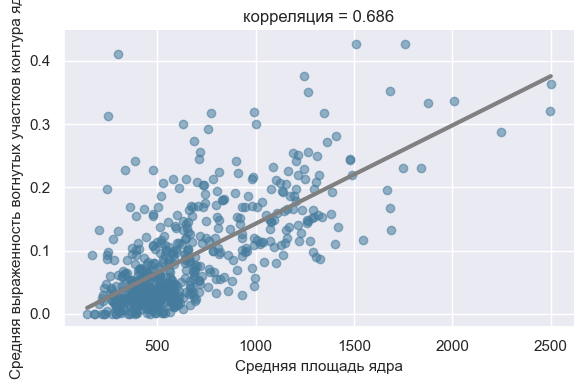

In [20]:
plot_scatter(
    df['mean area'],
    df['mean concavity'],
    x_label="Средняя площадь ядра",
    y_label="Средняя выраженность вогнутых участков контура ядра"
)

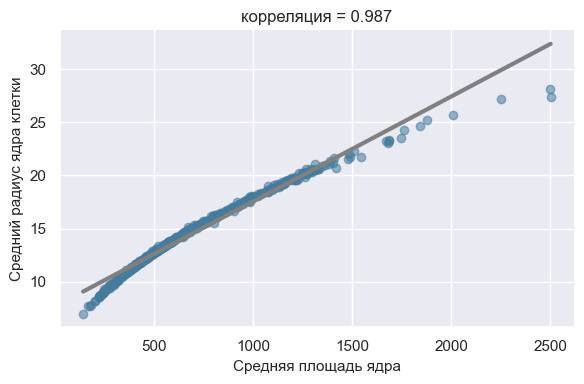

In [21]:
plot_scatter(
    df['mean area'],
    df['mean radius'],
    x_label="Средняя площадь ядра",
    y_label="Средний радиус ядра клетки"
)

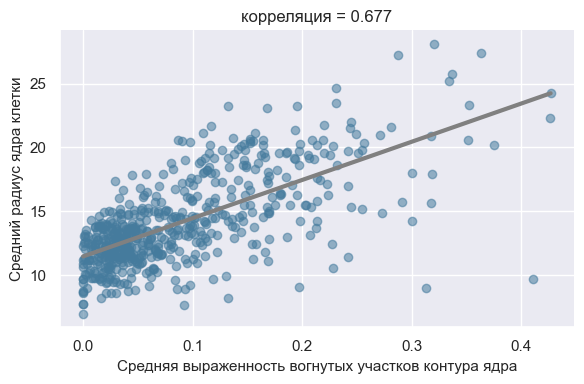

In [22]:
plot_scatter(
    df['mean concavity'],
    df['mean radius'],
    x_label="Средняя выраженность вогнутых участков контура ядра",
    y_label="Средний радиус ядра клетки"
)

Все 3 признака попарно имеют выраженную корреляцию.


0.686 - Между средней площадью и средней выраженностью вогнутых участков,


0.987 - Между средней площадью и средним радиусом ядра,


0.677 - Между средней выраженностью вогнутых участков и средним радиусом.

Теперь исследуйте частичную корреляцию для этих признаков

In [25]:
def partial_corr(df: pd.DataFrame, x: str, y: str, covars: list[str]) -> float:
    """
    Вычисляет частную корреляцию между x и y при фиксированных ковариатах через остатки OLS.

    Аргументы:
        df: DataFrame с исходными данными.
        x: Название столбца первой переменной.
        y: Название столбца второй переменной.
        covars: Список названий столбцов фиксируемых ковариат.

    Возвращает:
        Значение частной корреляции между x и y.
    """

    X = df[covars].astype(float).values
    X = np.column_stack([np.ones(len(X)), X])

    def resid(v):
        b, *_ = lstsq(X, v, rcond=None)
        return v - X @ b

    rx = resid(df[x].astype(float).values)
    ry = resid(df[y].astype(float).values)
    return np.corrcoef(rx, ry)[0, 1]

In [26]:
def plot_before_after(
    df: pd.DataFrame,
    x: str,
    y: str,
    z: str,
    x_label: str,
    y_label: str,
    z_label: str,
    n_bins: int = 3,
    bin_labels: list[str] | None = None,
) -> None:
    """
    Строит два скаттерплота рядом: без условия на z и при условии на z.

    Аргументы:
        df: DataFrame с исходными данными.
        x: Название столбца предиктора.
        y: Название столбца целевой переменной.
        z: Название столбца переменной-условия (контрольной переменной).
        x_label: Подпись оси X на обоих графиках.
        y_label: Подпись оси Y на обоих графиках.
        z_label: Отображаемое название контрольной переменной z.
        n_bins: Количество групп для дискретизации z, если z непрерывная.
        bin_labels: Пользовательские подписи для групп z; если None, генерируются автоматически.
    """

    COLORS = ["#e63946", "#2a9d8f", "#f4a261"]

    df2 = df[[x, y, z]].dropna().copy()

    # Дискретизация z
    if df2[z].nunique() <= n_bins + 2:
        df2["_group"] = df2[z].astype(int)
        groups = sorted(df2["_group"].unique())
        if bin_labels is None:
            bin_labels = [f"{z_label} = {g}" for g in groups]
    else:
        df2["_group"] = pd.qcut(df2[z], n_bins, labels=False, duplicates="drop")
        groups = sorted(df2["_group"].dropna().unique())
        if bin_labels is None:
            bin_labels = [f"{z_label}: низкий", f"{z_label}: средний", f"{z_label}: высокий"]

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    plot_scatter(df2[x], df2[y], x_label, y_label, title="Без условия", ax=axes[0])

    ax = axes[1]
    partial_r = partial_corr(df2, x, y, [z])
    for i, (g, lbl) in enumerate(zip(groups, bin_labels)):
        sub = df2[df2["_group"] == g]
        r_g = sub[x].corr(sub[y])
        color = COLORS[i % len(COLORS)]
        ax.scatter(
            sub[x],
            sub[y],
            alpha=0.65,
            color=color,
            edgecolors="white",
            linewidths=0.4,
            label=f"{lbl}  (r = {r_g:.3f})",
        )
        _add_regline(ax, sub[x].values, sub[y].values, color=color)

    ax.set_xlabel(x_label, fontsize=11)
    ax.set_ylabel(y_label, fontsize=11)
    ax.set_title(f"При условии «{z_label}», частная r = {partial_r:.3f}")
    ax.legend(fontsize=9.5, framealpha=0.9)
    ax.spines[["top", "right"]].set_visible(False)

    plt.tight_layout()
    plt.show()

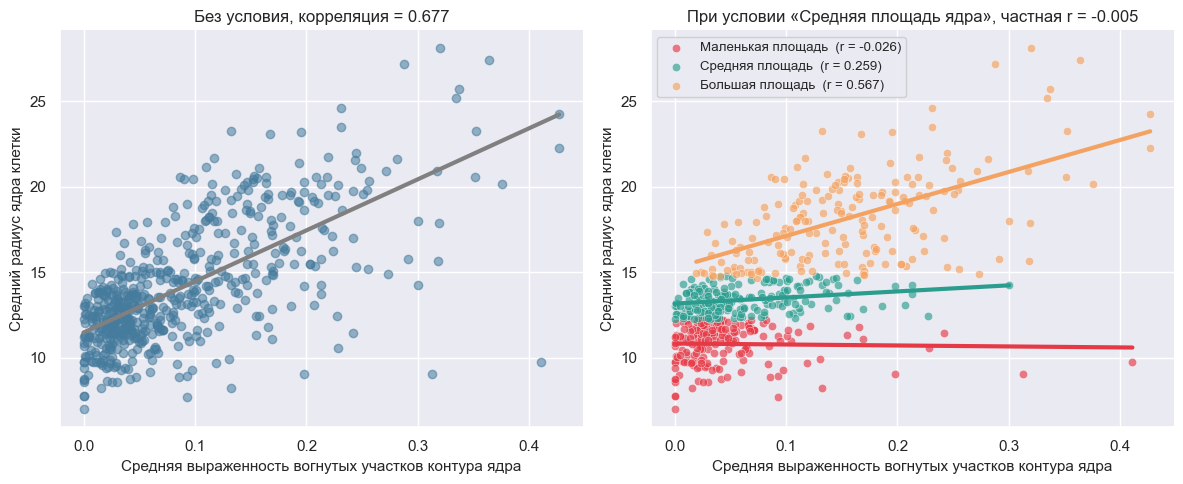

In [39]:
plot_before_after(
    df,
    'mean concavity',
    'mean radius',
    'mean area',
    x_label="Средняя выраженность вогнутых участков контура ядра",
    y_label="Средний радиус ядра клетки",
    z_label="Средняя площадь ядра",
    bin_labels=["Маленькая площадь", "Средняя площадь", "Большая площадь"],
)

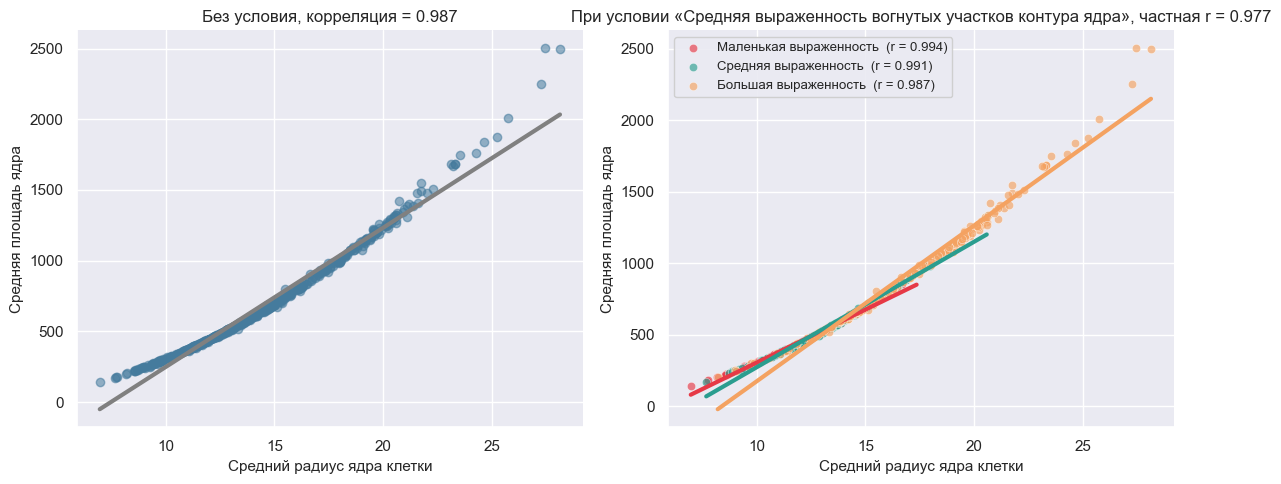

In [35]:
plot_before_after(
    df,
    'mean radius',
    'mean area',
    'mean concavity',
    x_label="Средний радиус ядра клетки",
    y_label="Средняя площадь ядра",
    z_label="Средняя выраженность вогнутых участков контура ядра",
    bin_labels=["Маленькая выраженность", "Средняя выраженность", "Большая выраженность"],
)

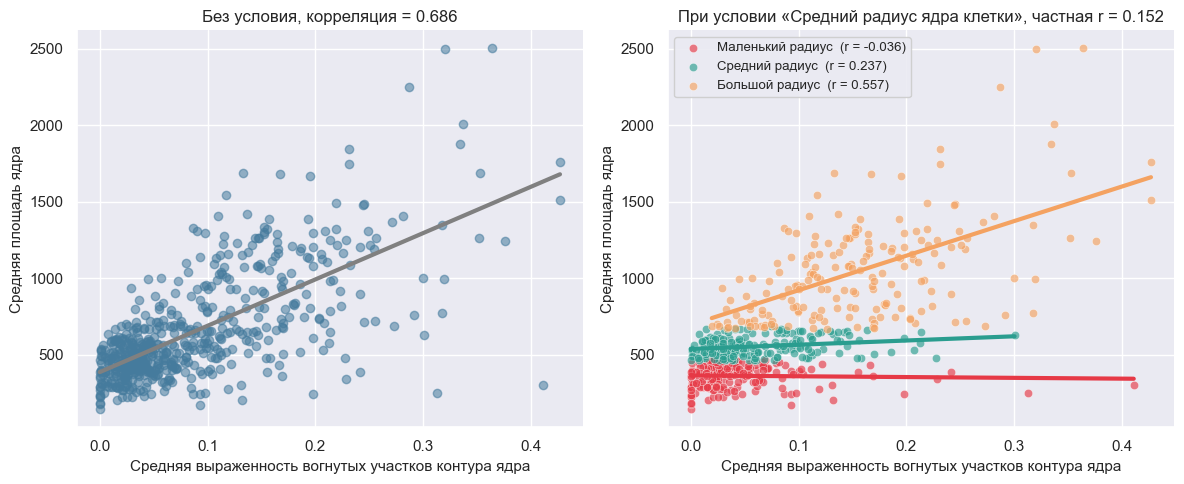

In [37]:
plot_before_after(
    df,
    'mean concavity',
    'mean area',
    'mean radius',
    x_label="Средняя выраженность вогнутых участков контура ядра",
    y_label="Средняя площадь ядра",
    z_label="Средний радиус ядра клетки",
    bin_labels=["Маленький радиус", "Средний радиус", "Большой радиус"],
)

Получили, что частичная корреляция пропадает между признаками:


-area и concativity, при фиксированном radius


-concativity и radius при фиксированном area

Осталась такая же сильная корреляция между radius и area, при фиксированном concativity

Можете ли вы **только лишь по данным** установить, какой из признаков является причиной, а какой &mdash; следствием? Сможет ли это сделать только по этим данным сколько угодно умная нейросеть?

Нет, например рассмотрим признаки:

Здесь я слово зависимость/независимость использую в смысле интерпретации коррелируемости.

radius и concativity - они зависимы, но при условии area получились независимы. То есть мы получили условие вилки/цепи.

Аналогично если рассмотрим concativity и area - они зависимы, но при условии radius они стали очень мало коррелированными, почти независимыми. Тоже условие вилки/цепи.

Из-за того что мы имеем только совместное распределение этих трех признаков, то из этих данных не можем получить, какая конкретная связь, а только, то, что это вилка/цепь c центром area или radius.

То есть получили глобально 6 вариантов:

area -> radius -> concativity

concativity -> radius -> area

concativity -> area -> radius

radius -> area -> concativity

radius <- area -> concativity

concativity <- radius -> area

Можете ли вы установить, какой из признаков является причиной, а какой &mdash; следствием, опираясь на свои представления о природе данных?

Я думаю самым логичным является вилка: area <- radius -> concativity

Чем больше радиус, тем больше площадь. Чем больше радиус, то есть чем больше опухаль разрослась в длину, тем большую неровность и выраженность изгибов границ она имеет.

Выводы:

Условное распредление позволяет лучше рассмотреть зависимость между признаками и позволяет откинуть некоторые типы свзяей. Но главное, что оно не дает ответ на вопрос какая именно связь, она лишь говорит о степени связи между признаками. То есть в любом случае для раскрытия истинной зависимости нужно экспертное мнение или человеческая логика. 

---
### Задача 2.

**1.** Пусть $X$ и $Y$ — случайные величины, причём $\mathsf{E} Y^2 < \infty$. Докажите формулу полной дисперсии
$$\mathsf{D} Y \;=\; \mathsf{E}\big[\mathsf{D}(Y\,|\,X)\big] \;+\; \mathsf{D}\big[\mathsf{E}(Y\,|\,X)\big].$$

<details>
<summary> ➡️ Если в твоем курсе теории вероятностей еще не было условных мат. ожиданий, кликни сюда </summary>
Тебе могут помочь следующие формулы:
    
1. Условная дисперсия определяется через условные математические ожидания $$\mathsf{D}(Y\mid X) = \mathsf{E}(Y^2\mid X) - \big[\mathsf{E}(Y\mid X)\big]^2.$$
    
2. Усреднение условного математического ожидания дает обычное математическое ожидание $$\mathsf{E}\big[\mathsf{E}(Y\mid X)\big] = \mathsf{E}Y.$$
</details>

$$
\begin{aligned}
E[D(Y|X)] + D[E(Y|X)] = \\
& = E\left[E(Y^2|X) - (E(Y|X))^2\right] + E\left[(E(Y|X) - E(E(Y|X)))^2\right] = \\
& = E(Y^2) - E\left[(E(Y|X))^2\right] + E\left[(E(Y|X))^2\right] - 2E\left[E(Y|X)\cdot E(E(Y|X))\right] + E\left[(E(E(Y|X)))^2\right] = \\
& = E(Y^2) - 2E\left[E(Y|X)\cdot E(Y)\right] + E\left[(E(Y))^2\right] = \\
& = E(Y^2) - 2E(Y)\cdot E(Y) + (E(Y))^2 = \\
& = E(Y^2) - (E(Y))^2 = D(Y)
\end{aligned}
$$

Пусть $X$ — это признаки группы (возраст, регион, профессия и т. п.), а $Y$ — измеряемая характеристика (таргет) внутри группы. Подробно проинтерпретируйте каждое слагаемое формулы.

$$E[D(Y|X)]$$ - матожидание условной дисперсии. Разброс (условная дисперсия) при фиксированом x и далее усредненный по всех X. То есть показывает средний разброс таргета при фиксировнном X.




$$D[E(Y|X)]$$ - дисперсия условного матожидания. То есть насколько сильно разбросано матожидание Y при разных X. Или можно сказать насколько сильно разбросан средний таргет при разных значениях X.


$$D(Y)$$ - полная дисперсия таргета. То есть общий разброс, вне зависимости от X.

**2.** На лекции был показан способ эмпирической оценки условного математического ожидания. Для тех же синтетических данных с лекции посчитайте приближенно 
* условную дисперсию и отобразите ее на графике (анимацию делать не нужно),
* все компоненты формулы полной дисперсии.

Подтвердилась ли формула?

In [41]:
def generate_data(n_samples: int = 500) -> tuple[np.ndarray, np.ndarray]:
    """
    Генерирует данные со сложной нелинейной зависимостью Y от X.

    Аргументы:
        n_samples: Количество генерируемых точек.

    Возвращает:
        Кортеж (X, Y) из отсортированных массивов признака и целевой переменной.
    """

    # X - равномерно распределенные точки на отрезке [0, 10]
    X = np.random.rand(n_samples) * 10

    # "Истинная" средняя зависимость Y от X (нелинейная)
    true_mean_func = lambda x: 2 * np.sin(x) + 0.1 * x**2

    # Гетероскедастичный шум: дисперсия шума зависит от X
    # Шум будет маленьким в начале и конце, и большим в середине
    noise_std = 0.5 + 2 * np.sin(np.pi * X / 10)

    # Генерируем Y с шумом
    Y = true_mean_func(X) + np.random.randn(n_samples) * noise_std

    # Добавляем "раздвоение" в области X от 7 до 9
    bifurcation_mask = (X > 6) & (X < 8)
    # Для половины точек в этой области "прыгаем" вверх или вниз
    bifurcation_indices = np.where(bifurcation_mask)[0]
    switch = np.random.rand(len(bifurcation_indices)) > 0.5

    Y[bifurcation_indices[switch]] += 5 * (1 - np.abs(X[bifurcation_indices[switch]] - 7) ** 2)
    Y[bifurcation_indices[~switch]] -= 5 * (1 - np.abs(X[bifurcation_indices[~switch]] - 7) ** 2)

    # Сортируем для удобства отрисовки
    sorted_indices = np.argsort(X)
    return X[sorted_indices], Y[sorted_indices]

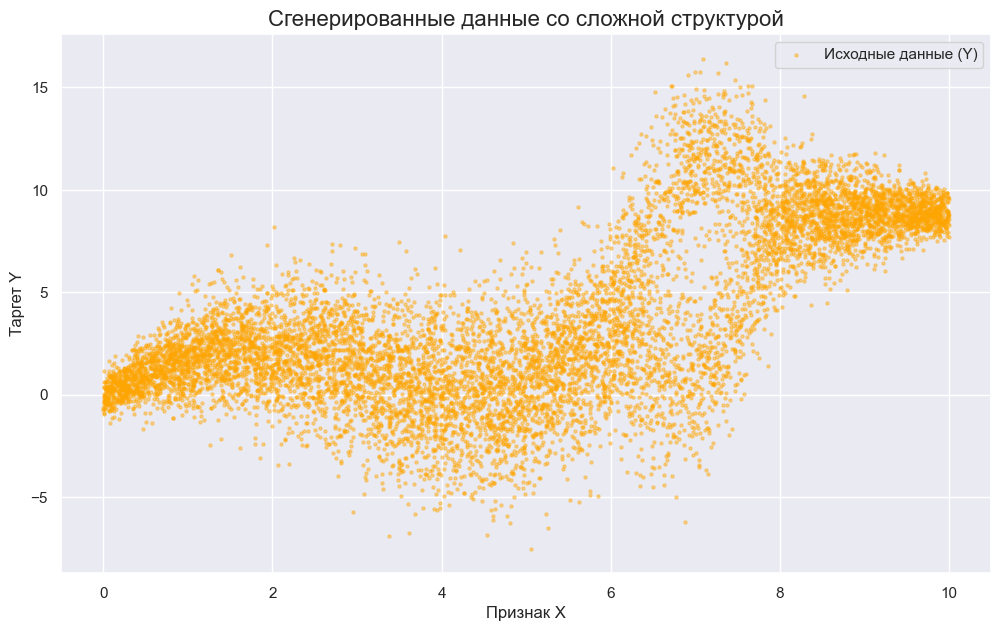

In [42]:
X, Y = generate_data(n_samples=10000)

plt.figure(figsize=(12, 7))
plt.scatter(X, Y, alpha=0.4, s=5, color="orange", label="Исходные данные (Y)")
plt.xlabel("Признак X")
plt.ylabel("Таргет Y")
plt.title("Сгенерированные данные со сложной структурой", fontsize=16)
plt.legend()
plt.show()

In [48]:
def uniform_kernel_D(
    x_target: float, X_train: np.ndarray, Y_train: np.ndarray, h: float
) -> float:
    """
    Вычисляет оценку дисперсии в точке с помощью равномерного ядра (локальное усреднение).

    Аргументы:
        x_target: Точка, в которой вычисляется оценка регрессии.
        X_train: Массив значений признака обучающей выборки.
        Y_train: Массив значений целевой переменной обучающей выборки.
        h: Ширина окна ядра.

    Возвращает:
        Оценку условной дисперсии ожидания в точке x_target или NaN,
        если в окно не попало ни одной точки.
    """

    # Находим индексы точек, попавших в окно
    kernel_weights = np.abs((X_train - x_target) / h) <= 1

    # Если в окно не попало ни одной точки, возвращаем NaN
    if not np.any(kernel_weights):
        return np.nan

    

    # Считаем дисперсию Y для этих точек
    return np.mean(Y_train[kernel_weights] ** 2) - np.mean(Y_train[kernel_weights]) ** 2

In [49]:
def uniform_kernel_regression(
    x_target: float, X_train: np.ndarray, Y_train: np.ndarray, h: float
) -> float:
    """
    Вычисляет оценку регрессии в точке с помощью равномерного ядра (локальное усреднение).

    Аргументы:
        x_target: Точка, в которой вычисляется оценка регрессии.
        X_train: Массив значений признака обучающей выборки.
        Y_train: Массив значений целевой переменной обучающей выборки.
        h: Ширина окна ядра.

    Возвращает:
        Оценку условного математического ожидания в точке x_target или NaN,
        если в окно не попало ни одной точки.
    """

    # Находим индексы точек, попавших в окно
    kernel_weights = np.abs((X_train - x_target) / h) <= 1

    # Если в окно не попало ни одной точки, возвращаем NaN
    if not np.any(kernel_weights):
        return np.nan

    # Считаем среднее Y для этих точек
    return np.mean(Y_train[kernel_weights])

In [50]:
# Создаем сетку точек, в которых будем вычислять все статистики
x_grid = np.linspace(X.min(), X.max(), 200)

# Обозначаем окно

h = 0.2

# Вычисляем предсказания для каждой точки сетки

D_Y_X_uniform = [uniform_kernel_D(xt, X, Y, h=0.2) for xt in x_grid]

E_Y_X_uniform = [uniform_kernel_regression(xt, X, Y, h=0.2) for xt in x_grid]

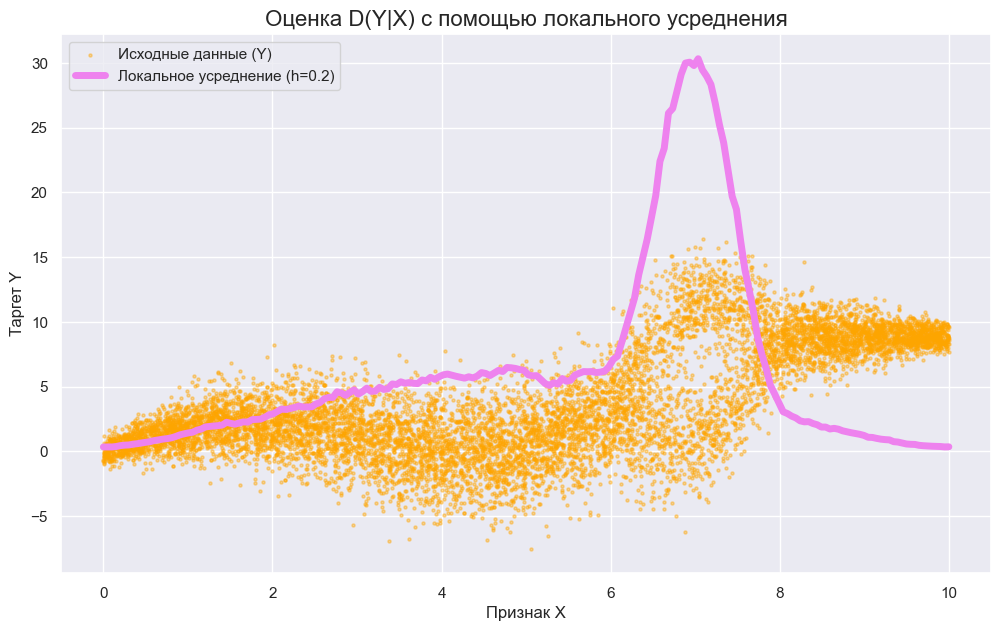

In [51]:
plt.figure(figsize=(12, 7))
plt.scatter(X, Y, alpha=0.4, s=5, color="orange", label="Исходные данные (Y)")
plt.plot(x_grid, D_Y_X_uniform, color="violet", linewidth=5, label=f"Локальное усреднение (h={h})")
plt.xlabel("Признак X")
plt.ylabel("Таргет Y")
plt.title("Оценка D(Y|X) с помощью локального усреднения", fontsize=16)
plt.legend()
plt.show()

Теперь проверим формулу:

In [53]:
E_D_Y_X_uniform = np.mean(D_Y_X_uniform)

D_E_Y_X_uniform = np.mean(np.array(E_Y_X_uniform) ** 2) - np.mean(E_Y_X_uniform) ** 2

D_Y = np.mean(Y ** 2) - np.mean(Y) ** 2

print(f'Левая часть формулы: {E_D_Y_X_uniform + D_E_Y_X_uniform}\nПравая часть формулы: {D_Y}')

Левая часть формулы: 17.365953132146235
Правая часть формулы: 17.35253665302345


In [54]:
print('E(D(Y|X)) =  ', E_D_Y_X_uniform, ', D(E(Y|X)) = ', D_E_Y_X_uniform)

E(D(Y|X)) =   6.254330332547109 , D(E(Y|X)) =  11.111622799599125


Получили значения очень близкие, то есть формула подтвердилась. Погрешность может быть вызвана приближенным вычислением условного матожидания и условной дисперсии.

Опираясь на теорему о наилучшем приближении таргета по признакам (посмотрите в ноутбуе с занятия) и формулу полной дисперсии определите, какую долю дисперсии данных $Y$ оптимальная модель регрессии может "объяснить" на основе признаков $X$, а какая доля дисперсии остается необъясненной.

Объяснимая часть дисперсии, это слагаемое $D[E(Y|X)]$. То есть та часть, которая обуславливается дисперсией средних значений между разными группами. Необъяснимая часть дисперсии это $E[D(Y|X)]$, то есть среднее отклонение Y внутри группы. То есть то, что мы не можем объяснить, разбив на группы по признаку X.

Определим коэффициент детерминации как 
$$R^2 = \frac{\mathsf{D}\big[\mathsf{E}(Y|X)\big]}{\mathsf{D} Y},$$
формула для выборочного коэффициента детерминации была в ноутбуке по линейной регрессии. Покажите, что $0 \leqslant R^2 \leqslant 1$. Объясните, при каких $(X, Y)$ достигаются крайние значения $R^2 = 0$ и $R^2 = 1$ и каким случаям они соответствуют.

Разделим обе части формулы полной дисперсии на $DY$, тогда получим:
$$1 = \frac{E[D(Y|X)]}{DY} + \frac{D[E(Y|X)]}{DY}$$

$$R^2 = 1 - \frac{E[D(Y|X)]}{DY}$$

Т.к. $E[D(Y|X)] > 0, DY > 0, D[E(Y|X)] > 0$, то $0 \geq R^2 \geq 1$

$R^2 = 1$, при $E[D(Y|X)] = 0$, т.е. при $D(Y|X) = 0$ почти везде. То есть дисперсия полностью объясняется признаком X и дисперсии таргета внутри одной группы нет.

$R^2 = 0$, при $D[E(Y|X)] = 0$, т.е. при $E(Y|X) = const$ почти везде. То есть дисперсия вообще не объясняется признаком X и матожидание таргета в разных группах равно, то есть дисперсия полностью объясняется дисперсией таргета внутри каждой группы.

---
### Задача 3.

Пусть $\mathscr{X} = \mathbb{R}^2$ — пространство признаков, $\mathscr{Y} = \{0, 1\}$ — множество классов. Рассмотрим байесовский классификатор, в котором зададам условное распределение $X$ при условии $Y=k$ как $\mathcal{N}(a_k, \Sigma_k)$. Разделяющей поверхностью между классами $k$ и $\ell$ называется множество точек пространства признаков, для которых вероятность этих двух классов одинакова.

Приведите примеры таких параметров $a_k, \Sigma_k$ и вероятностей $\mathsf{P}(Y = k)$, при которых разделяющая поверхность является
* гиперболой;
* параболой;
* двумя параллельными прямыми;
* двумя пересекающимися прямыми.

*Примечание.* Можно подобрать выборку, посчитать оценки со страшными числами. Но еще лучше &mdash; немного подумать и привести пример с "красивыми" числами без какого-либо подбора выборки. В данном случае это довольно просто, а также позволяет лучше разобраться в параметрах многомерного нормального распределения.


Поймем, что такое разделяющая поверхность:  
по ф-ле Байеса

$$
P(Y = k \mid X = x) = \frac{P(Y = k)\, p(x \mid Y = k)}{p(x)}
$$

$$
P(Y = 0 \mid X = x) \;\vee\; P(Y = 1 \mid X = x)
\qquad \big| \cdot p(x)
$$

$$
P(Y = 0)\, p(x \mid Y = 0) \;\vee\; P(Y = 1)\, p(x \mid Y = 1)
$$

Возьмем $\log$ от обеих частей и подставим нормальное распределение:

$$
\log(\pi_0) - \log 2\pi - \frac{1}{2}\log|\Sigma_0|
- \frac{1}{2}(x-a_0)^T \Sigma_0^{-1}(x-a_0)
\;\vee\;
\log(\pi_1) - \log 2\pi - \frac{1}{2}\log|\Sigma_1|
- \frac{1}{2}(x-a_1)^T \Sigma_1^{-1}(x-a_1)
$$

Найдем равенство:

$$
\log \frac{|\Sigma_1|}{|\Sigma_0|}
- 2\log \frac{\pi_1}{\pi_0}
+ (x-a_1)^T \Sigma_1^{-1}(x-a_1)
- (x-a_0)^T \Sigma_0^{-1}(x-a_0)
= 0
$$

Это и есть разделяющая линия.

1) Гипербола.

$$
a_0 = a_1 =
\begin{pmatrix}
0 \\
0
\end{pmatrix},
\qquad
\pi_1 = \pi_0 = \frac{1}{2},
\qquad
\Sigma_1 =
\begin{pmatrix}
5 & 0 \\
0 & \frac{1}{10}
\end{pmatrix},
\qquad
\Sigma_0 =
\begin{pmatrix}
1 & 0 \\
0 & 1
\end{pmatrix}
$$

$$
\Sigma_1^{-1} =
\begin{pmatrix}
\frac{1}{5} & 0 \\
0 & 10
\end{pmatrix},
\qquad
\Sigma_0^{-1} =
\begin{pmatrix}
1 & 0 \\
0 & 1
\end{pmatrix}
$$

Тогда получим:

$$
\frac{1}{5}x_1^2 + 10x_2^2 - x_1^2 - x_2^2 + \log \frac{1}{2} = 0
$$

$$
-\frac{4}{5}x_1^2 + 9x_2^2 = \log 2
$$

$$
9x_2^2 - \frac{4}{5}x_1^2 - \log 2 = 0
\quad \text{— гипербола.}
$$

2) 2 пар. прямые

$$
a_1 = a_0 =
\begin{pmatrix}
0 \\
0
\end{pmatrix},
\qquad
\pi_0 = \pi_1 = \frac{1}{2}
$$

$$
\Sigma_0 =
\begin{pmatrix}
1 & 0 \\
0 & 1
\end{pmatrix},
\qquad
\Sigma_1 =
\begin{pmatrix}
\frac{1}{3} & 0 \\
0 & 1
\end{pmatrix}
$$

$$
\Sigma_0^{-1} =
\begin{pmatrix}
1 & 0 \\
0 & 1
\end{pmatrix},
\qquad
\Sigma_1^{-1} =
\begin{pmatrix}
3 & 0 \\
0 & 1
\end{pmatrix}
$$

Тогда получаем после подставки:

$$
3x_1^2 + x_2^2 - x_1^2 - x_2^2 = \log 3
$$

$$
2x_1^2 = \log 3
$$

$$
x_1 = \pm \sqrt{\frac{\log 3}{2}}
$$


3) Пересекающиеся прямые

$$
a_1 = a_0 =
\begin{pmatrix}
0 \\
0
\end{pmatrix}
$$

$$
\pi_1 = \pi_0 = \frac{1}{2}
$$

$$
\Sigma_0 =
\begin{pmatrix}
1 & 0 \\
0 & 1
\end{pmatrix},
\qquad
\Sigma_1 =
\begin{pmatrix}
\frac{1}{3} & 0 \\
0 & 3
\end{pmatrix}
$$

$$
\Sigma_0^{-1} =
\begin{pmatrix}
1 & 0 \\
0 & 1
\end{pmatrix},
\qquad
\Sigma_1^{-1} =
\begin{pmatrix}
3 & 0 \\
0 & \frac{1}{3}
\end{pmatrix}
$$

Подставим:

$$
3x_1^2 + \frac{1}{3}x_2^2 - x_1^2 - x_2^2 = 0,
\qquad
\text{т.к. } |\Sigma_0| = |\Sigma_1|
$$

$$
2x_1^2 = \frac{2}{3}x_2^2
$$

$$
|x_1| = \frac{1}{\sqrt{3}}|x_2|
\Longleftrightarrow
x_1 = \frac{1}{\sqrt{3}}x_2, \\
x_1 = -\frac{1}{\sqrt{3}}x_2
$$

4) Парабола

$$
a_0 =
\begin{pmatrix}
0 \\
0
\end{pmatrix},
\qquad
a_1 =
\begin{pmatrix}
0 \\
1
\end{pmatrix}
$$

$$
\Sigma_0 =
\begin{pmatrix}
1 & 0 \\
0 & 1
\end{pmatrix},
\qquad
\Sigma_1 =
\begin{pmatrix}
\frac{1}{2} & 0 \\
0 & 1
\end{pmatrix}
$$

$$
\Sigma_1^{-1} =
\begin{pmatrix}
2 & 0 \\
0 & 1
\end{pmatrix},
\qquad
\Sigma_0^{-1} =
\begin{pmatrix}
1 & 0 \\
0 & 1
\end{pmatrix}
$$

$$
\pi_0 = \pi_1 = \frac{1}{2}
$$

Подставим в наше ур-ние:

$$
x_1^2 - 2x_2 + 1 - \log 2 = 0
$$

Это парабола.

---
© 2026 команда <a href="https://thetahat.ru/">ThetaHat</a> для ВвАД